In [ ]:
from selenium import webdriver
from selenium.webdriver.firefox.options import Options
from selenium.webdriver.common.by import By
import time
import re
import pandas as pd

# Ustawia opcje przeglądarki Firefox na tryb headless (bez interfejsu graficznego)
options = Options()
options.headless = True

# Inicjalizuje przeglądarkę Firefox z wybranymi opcjami
driver = webdriver.Firefox(options=options)

try:
    # Otwiera stronę z godzinami otwarcia zamku Łańcut
    driver.get("https://www.zamek-lancut.pl/godziny-otwarcia")
    # Czeka 2 sekundy, aby strona się wczytała
    time.sleep(2)

    # Znajduje wszystkie przyciski "czytaj więcej" na stronie
    czytaj_wiecej_buttons = driver.find_elements(By.LINK_TEXT, "czytaj więcej")
    # Pobiera linki (adresy URL) z atrybutu href tych przycisków
    links = [btn.get_attribute("href") for btn in czytaj_wiecej_buttons if btn.get_attribute("href")]

    # Inicjalizuje listy do przechowywania danych o biletach oraz tekstów stron
    bilety_data = []
    txt_results = []

    # Iteruje przez wszystkie znalezione linki
    for link in links:
        # Otwiera stronę z danym linkiem
        driver.get(link)
        # Czeka 2 sekundy na załadowanie strony
        time.sleep(2)

        try:
            # Pobiera zawartość artykułu na stronie (sekcja z tekstem)
            content_div = driver.find_element(By.CSS_SELECTOR, "div.com-content-article__body")
            # Pobiera cały tekst z tej sekcji
            full_text = content_div.text

            # Wyszukuje sekcję dotyczącą biletów wstępu za pomocą wyrażenia regularnego
            bilety_section = re.search(r"BILETY WSTĘPU:(.*?)(\n\n|$)", full_text, re.DOTALL | re.IGNORECASE)
            # Pobiera znalezioną sekcję lub pusty tekst jeśli jej nie ma
            bilety_text = bilety_section.group(0) if bilety_section else ""

            # Jeśli sekcja biletów istnieje, usuwa ją z pełnego tekstu, w przeciwnym wypadku pozostawia cały tekst
            if bilety_text:
                text_wo_bilety = full_text.replace(bilety_text, "").strip()
            else:
                text_wo_bilety = full_text.strip()

            # Filtruje linie tekstu, aby usunąć fragmenty dotyczące "Rodzaje biletów" i "Zasady zwiedzania"
            filtered_lines = []
            for line in text_wo_bilety.splitlines():
                if ("Rodzaje biletów" in line) or ("Zasady zwiedzania" in line):
                    continue
                filtered_lines.append(line)
            text_wo_bilety = "\n".join(filtered_lines).strip()

            # Dodaje przetworzony tekst wraz z linkiem do wyników tekstowych
            txt_results.append(f"{link}\n{text_wo_bilety}\n\n{'-'*80}\n\n\n")

            # Jeśli sekcja biletów istnieje, próbuje wyodrębnić typ biletu i cenę
            if bilety_text:
                lines = bilety_text.splitlines()
                for line in lines:
                    # Dopasowuje linię w formacie "Typ biletu – cena zł"
                    m = re.match(r"(\w+)\s*[–-]\s*(\d+)\s*zł", line.strip(), re.IGNORECASE)
                    if m:
                        typ = m.group(1).strip()
                        cena = int(m.group(2))
                        # Dodaje dane biletu do listy jako słownik
                        bilety_data.append({"link": link, "typ_biletu": typ, "cena": cena})

        except Exception as e:
            # W przypadku błędu podczas pobierania danych dodaje informację o błędzie do wyników tekstowych
            txt_results.append(f"{link}\nBłąd podczas pobierania: {str(e)}\n\n")

    # Zapisuje wszystkie zebrane teksty do pliku tekstowego
    with open("godziny_otwarcia.txt", "w", encoding="utf-8") as f:
        f.writelines(txt_results)

    # Jeśli zebrano dane o biletach, zapisuje je do pliku CSV
    if bilety_data:
        df = pd.DataFrame(bilety_data)
        df.to_csv("ceny_biletow.csv", index=False, encoding="utf-8-sig")
    else:
        # Informuje, że nie znaleziono żadnych cen biletów
        print("Nie znaleziono żadnych cen biletów.")

finally:
    # Zamyka przeglądarkę niezależnie od wyniku działania kodu
    driver.quit()

print("Gotowe! Dane zapisane w 'godziny_otwarcia.txt' i 'ceny_biletow.csv'")


Gotowe! Dane zapisane w 'godziny_otwarcia.txt' i 'ceny_biletow.csv'


https://www.zamek-lancut.pl/godziny-otwarcia
<html lang="pl-pl" dir="ltr"><head>
    

    

    <meta charset="utf-8">
	<meta name="author" content="Muzeum Łańcut">
	<meta name="generator" content="Joomla! - Open Source Content Management">
	<title>Godziny otwarcia i ceny biletów</title>
	<link href="https://www.zamek-lancut.pl/media/system/images/favicon.ico" rel="alternate icon" type="image/x-icon">
	<link href="/favicon.ico" rel="icon" type="image/vnd.microsoft.icon">

    <style>.pbck-container { max-width: 1000px}</style>
	<style>@media only screen and (min-width:801px){
.ckhide5 { display: none !important; } 
.ckstack5 > .inner { display: block; }
.ckstack5 > .inner > .blockck { float: none !important; width: auto !important; display: block; margin-left: 0 !important;}
}@media only screen and (max-width:800px) and (min-width:641px){
.ckhide4 { display: none !important; } 
.ckstack4 > .inner { display: block; }
.ckstack4 > .inner > .blockck { float: none !important; width: auto !
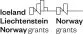

True

In [19]:
from selenium.webdriver import Firefox, Chrome, Edge
from selenium.webdriver import FirefoxOptions, ChromeOptions, EdgeOptions

driverFF = Firefox()

driverFF.get('https://www.zamek-lancut.pl/godziny-otwarcia')

print(driverFF.current_url)
print(driverFF.page_source)

driverFF.save_full_page_screenshot('ss.png')